# Notebook 07: Convolutions - The Heart of Computer Vision

------------------------------------------------------------------------

## What This Notebook Covers

This notebook introduces **convolutions**, the fundamental operation behind Convolutional Neural Networks (CNNs) that have revolutionized computer vision. We will learn:

1.  **What is a convolution?** - The mathematical operation explained simply
2.  **Kernels (Filters)** - Small matrices that detect features like edges
3.  **How to apply convolutions manually** - Understanding by doing
4.  **PyTorch convolutions** - The fast, efficient way
5.  **Strides and Padding** - Controlling output size
6.  **Building a CNN** - Putting it all together
7.  **Receptive Field** - How much of the input each output "sees"
8.  **Color Images** - Handling RGB channels

------------------------------------------------------------------------

### Why Are Convolutions Important?

Before CNNs, computer vision struggled with:

- Images have millions of pixels - too many parameters for fully connected networks
- Objects can appear anywhere in an image - we need translation invariance
- Local patterns matter - a vertical edge is a vertical edge, wherever it appears

**Convolutions solve all these problems:**

- They use **parameter sharing** - the same small filter is applied everywhere
- They detect **local patterns** - edges, textures, shapes
- They are **translation invariant** - detect a cat whether it's in the corner or center

------------------------------------------------------------------------

## Google Colab Setup

Run the cells below **once** at the start of each Colab session. They mount Google Drive, set the working directory, install the standard packages, and clone the `miniai` library from the fast.ai Part 2 course repo so the `from miniai.X import *` lines work.

**GPU note:** Uses small models on CPU; a GPU runtime speeds things up but isn't required.

In [204]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [205]:
import os
os.chdir('/content/drive/MyDrive/Fast.AI_Colab')
print(os.getcwd())

/content/drive/MyDrive/Fast.AI_Colab


In [206]:
# Install required packages
!pip install -q fastcore fastai diffusers datasets torcheval accelerate

# Clone the fast.ai Part 2 course repo to get the miniai library
if not os.path.exists('course22p2'):
    !git clone https://github.com/fastai/course22p2.git

# Add miniai to the Python path
import sys
sys.path.insert(0, os.path.join(os.getcwd(), 'course22p2'))

# Verify miniai is accessible
try:
    import miniai
    print(f'miniai loaded successfully from: {miniai.__file__}')
except ImportError:
    print('ERROR: miniai not found. Check that course22p2 was cloned correctly.')

miniai loaded successfully from: /content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/__init__.py


---

*The cells above are Colab-specific setup. The content below is the same as the source notebook (`07_convolutions_explained.ipynb`), unchanged.*

---

## Part 1: Setup and Data Loading

------------------------------------------------------------------------

First, let's import all the libraries we need and load our data.

In [207]:
# =====================================================
# IMPORTS - Libraries we'll use throughout this notebook
# =====================================================

# --- PyTorch Core ---
import torch                          # The main PyTorch library
from torch import nn                  # Neural network module (layers, models)
from torch import tensor              # For creating tensors easily
import torch.nn.functional as F       # Functional operations (conv2d, relu, etc.)
from torch import optim               # Optimizers (SGD, Adam, etc.)
from torch.utils.data import DataLoader  # For batching data

# --- Data Handling ---
import pickle                         # For loading saved Python objects
import gzip                           # For reading compressed files
from pathlib import Path              # Modern path handling

# --- Visualization ---
import matplotlib as mpl              # Matplotlib configuration
import matplotlib.pyplot as plt       # For creating plots
import numpy as np                    # Numerical operations
import pandas as pd                   # Data manipulation (for nice tables)

# --- Other ---
import math, os, time                 # Standard utilities

In [208]:
from miniai.training import *
from miniai.datasets import *

In [209]:
# =====================================================
# MATPLOTLIB CONFIGURATION
# =====================================================

# Set the default colormap for images to grayscale
# This is appropriate for MNIST digits which are black and white
mpl.rcParams['image.cmap'] = 'gray'

In [210]:
# =====================================================
# HELPER FUNCTION: Display Images
# =====================================================

def show_image(im, ax=None, figsize=(3,3), title=None, noframe=True, cmap=None):
    """
    Display a single image using matplotlib.

    Arguments:
        im      - The image to display (can be a PyTorch tensor or a NumPy array)
        ax      - An existing matplotlib 'axis' (a subplot area). If None, we create a new one.
        figsize - The physical size of the image window in inches (width, height)
        title   - A text string to show above the image
        noframe - If True, it hides the x and y axis numbers and the border box
        cmap    - 'Colormap' (e.g., 'gray'). Tells matplotlib how to map numbers to colors.
    """
    # If the user didn't provide a specific subplot area (ax), create a new figure and axis
    if ax is None:
        # plt.subplots returns a Figure (the whole window) and an Axis (the specific drawing area)
        fig, ax = plt.subplots(figsize=figsize)

    # Check if 'im' is a PyTorch tensor (it will have a '.cpu' method)
    if hasattr(im, 'cpu'):
        # .detach() stops tracking math history; .cpu() moves data from GPU to computer memory
        im = im.detach().cpu()

    # Check if 'im' can be converted to a NumPy array (which matplotlib requires)
    if hasattr(im, 'numpy'):
        # Convert the PyTorch/Fastai object into a standard NumPy numerical array
        im = im.numpy()

    # Use the axis 'imshow' method to actually draw the array as an image
    ax.imshow(im, cmap=cmap)

    # If a title string was provided, tell the axis to display it at the top
    if title is not None:
        ax.set_title(title)

    # If noframe is True, we tell the axis to turn off the visibility of the border and scales
    if noframe:
        ax.axis('off')

    # Return the axis object so the user can modify it further if they want
    return ax

def show_images(ims, nrows=1, ncols=None, figsize=None, titles=None):
    """
    Display multiple images in a organized grid (rows and columns).

    Arguments:
        ims     - A list or collection of images
        nrows   - How many horizontal rows you want in your grid
        ncols   - How many vertical columns. If None, it calculates it based on total images.
        figsize - The total size of the entire grid window
        titles  - A list of text strings, one for each image
    """
    # If columns aren't specified, divide total images by rows to find needed columns
    if ncols is None:
        # '//' is integer division (e.g., 10 // 3 = 3)
        ncols = len(ims) // nrows

    # If no total figure size is set, automatically size it (3 inches per image)
    if figsize is None:
        figsize = (ncols * 3, nrows * 3)

    # Create the grid of subplots. 'fig' is the window, 'axs' is a list/grid of drawing areas.
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)

    # If there is more than one image, 'axs' is a 2D grid. .flatten() turns it into a 1D list.
    # If there's only one image, we wrap it in a list [axs] so we can still loop over it.
    axs = axs.flatten() if hasattr(axs, 'flatten') else [axs]

    # Loop through the list of images and the list of subplot areas simultaneously
    # 'i' is the current index (0, 1, 2...), 'im' is the image, 'ax' is the specific subplot
    for i, (im, ax) in enumerate(zip(ims, axs)):
        # Check if we have a list of titles; if so, pick the title at the current index
        title = titles[i] if titles else None
        # Call our single-image function defined above to draw the image into this subplot
        show_image(im, ax=ax, title=title)

    # Adjust the spacing so that titles and images don't overlap with each other
    plt.tight_layout()

    # Return the figure and all the subplot areas
    return fig, axs

## Function 1: `show_image` — Display a Single Image

### The Comment Header

    # =====================================================
    # HELPER FUNCTION: Display Images
    # =====================================================

These are just **decorative comments**. They do nothing in the code. They are there to visually separate this section and tell the reader "this section is about helper functions for displaying images."

------------------------------------------------------------------------

### Function Definition

    def show_image(im, ax=None, figsize=(3,3), title=None, noframe=True, cmap=None):

This line **defines a function** called `show_image`. Let's break down each **parameter** (input):

| Parameter | Default Value | What It Does                                                                                                                                                 |
|-----------|---------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `im`      | *(required)*  | The image you want to display. Could be a PyTorch tensor or a NumPy array.                                                                                   |
| `ax`      | `None`        | An optional matplotlib axes object. If you already have a subplot ready, pass it here. If `None`, the function creates a new figure.                         |
| `figsize` | `(3, 3)`      | The size of the figure in inches — 3 inches wide by 3 inches tall. Only used when `ax` is `None`.                                                            |
| `title`   | `None`        | An optional title string to show above the image. If `None`, no title is shown.                                                                              |
| `noframe` | `True`        | If `True`, the axis borders and tick marks are hidden (cleaner look). If `False`, they are shown.                                                            |
| `cmap`    | `None`        | Short for "colormap." Controls how pixel values are colored. For example, `'gray'` makes a grayscale image. If `None`, matplotlib uses its default colormap. |

------------------------------------------------------------------------

### Creating a New Figure (If Needed)

    if ax is None:
            fig, ax = plt.subplots(figsize=figsize)

**Logic:** If the caller did NOT provide an existing axes object (i.e., `ax` is `None`), we need to create one from scratch.

- `plt.subplots(figsize=figsize)` creates a new figure and a single axes (subplot) inside it.
- `fig` receives the figure object (the entire canvas).
- `ax` receives the axes object (the drawing area where the image will go).
- `figsize=figsize` sets the figure size to whatever was passed in (default is 3×3 inches).

**Why this matters:** This makes the function flexible. You can use it standalone (it creates its own figure) OR embed it inside a grid of subplots (by passing an existing `ax`).

------------------------------------------------------------------------

### Converting a PyTorch Tensor to NumPy

    if hasattr(im, 'cpu'):
            im = im.detach().cpu()

**Logic:** This checks if the image (`im`) has a `.cpu()` method. If it does, it's very likely a **PyTorch tensor**.

- `hasattr(im, 'cpu')` → returns `True` if `im` has an attribute or method called `cpu`. This is a safe way to check without crashing.
- `im.detach()` → Detaches the tensor from PyTorch's **computation graph**. In deep learning, tensors track operations for backpropagation (gradient calculation). We don't need gradients for displaying an image, so we detach it.
- `.cpu()` → Moves the tensor from the **GPU** (if it was there) to the **CPU**. Matplotlib cannot display GPU tensors directly.

    if hasattr(im, 'numpy'):
            im = im.numpy()

**Logic:** This checks if `im` has a `.numpy()` method. After the previous step, it's now a CPU tensor.

- `im.numpy()` → Converts the PyTorch tensor into a **NumPy array**, which matplotlib can understand and display.

**Why two separate checks?** Because the image might already be a NumPy array (not a tensor), in which case both checks would be `False` and the image passes through unchanged. This makes the function work with **both** tensors and NumPy arrays.

------------------------------------------------------------------------

### Displaying the Image

    ax.imshow(im, cmap=cmap)

- `ax.imshow()` is matplotlib's function to **display an image** on an axes.
- `im` is the image data (now guaranteed to be a NumPy array or already compatible).
- `cmap=cmap` passes the colormap. If `cmap` is `None`, matplotlib uses its default (which is `'viridis'` for single-channel images or normal RGB for 3-channel images).

------------------------------------------------------------------------

### Setting the Title

    if title is not None:
            ax.set_title(title)

**Logic:** If the user provided a title string, display it above the image.

- `ax.set_title(title)` sets the title text on the axes.
- If `title` is `None` (the default), this block is skipped entirely, and no title is shown.

------------------------------------------------------------------------

### Removing the Frame

    if noframe:
            ax.axis('off')

**Logic:** If `noframe` is `True` (which it is by default), hide all axis decorations.

- `ax.axis('off')` removes the x-axis, y-axis, tick marks, tick labels, and the border around the image.
- This gives a **clean look** — just the image with nothing around it.
- If you set `noframe=False` when calling the function, the axis frame and tick marks will be visible (useful for debugging pixel coordinates).

------------------------------------------------------------------------

### Returning the Axes

    return ax

The function returns the `ax` object. This is useful because:

1.  If the function created a new axes, the caller can use it to add more things (like annotations).
2.  If an existing axes was passed in, returning it maintains a consistent interface.

------------------------------------------------------------------------

## Function 2: `show_images` — Display Multiple Images in a Grid

### Function Definition

    def show_images(ims, nrows=1, ncols=None, figsize=None, titles=None):

This defines a function to display **multiple images** arranged in a grid layout.

| Parameter | Default Value | What It Does                                                                 |
|-----------|---------------|------------------------------------------------------------------------------|
| `ims`     | *(required)*  | A **list** of images to display.                                             |
| `nrows`   | `1`           | Number of rows in the grid. Default is 1 (all images in a single row).       |
| `ncols`   | `None`        | Number of columns. If `None`, it's calculated automatically.                 |
| `figsize` | `None`        | Size of the overall figure. If `None`, it's calculated automatically.        |
| `titles`  | `None`        | A list of title strings, one for each image. If `None`, no titles are shown. |

------------------------------------------------------------------------

### Auto-Calculating the Number of Columns

    if ncols is None:
            ncols = len(ims) // nrows

**Logic:** If the user didn't specify how many columns they want, calculate it automatically.

- `len(ims)` → the total number of images.
- `// nrows` → integer division by the number of rows.
- **Example:** If you have 6 images and 2 rows → `6 // 2 = 3` columns.
- **Example:** If you have 5 images and 1 row → `5 // 1 = 5` columns.

**Note:** This uses integer division (`//`), so if the images don't divide evenly (e.g., 7 images, 2 rows → `7 // 2 = 3` columns = 6 slots), the last image won't be displayed. This is a simple approach that works well for evenly divisible cases.

------------------------------------------------------------------------

### Auto-Calculating the Figure Size

    if figsize is None:
            figsize = (ncols * 3, nrows * 3)

**Logic:** If no figure size was provided, calculate a reasonable default.

- Each image gets a 3×3 inch space.
- `ncols * 3` → total width in inches.
- `nrows * 3` → total height in inches.
- **Example:** 2 rows, 3 columns → figure is 9 inches wide × 6 inches tall.

------------------------------------------------------------------------

### Creating the Grid of Subplots

    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)

- `plt.subplots(nrows, ncols, ...)` creates a figure with a **grid** of axes (subplots).
- `fig` → the overall figure object.
- `axs` → the axes objects. This could be:
  - A **2D array** of axes (if `nrows > 1` and `ncols > 1`)
  - A **1D array** of axes (if either `nrows` or `ncols` is 1)
  - A **single axes object** (if both `nrows` and `ncols` are 1)

------------------------------------------------------------------------

### Flattening the Axes Array

    axs = axs.flatten() if hasattr(axs, 'flatten') else [axs]

**Logic:** We need `axs` to be a **flat, 1D list** so we can loop through it easily.

- `hasattr(axs, 'flatten')` → checks if `axs` is a NumPy array (which has a `.flatten()` method). This is true when there are multiple subplots.
- `axs.flatten()` → converts a 2D array like `[[ax1, ax2], [ax3, ax4]]` into a 1D array `[ax1, ax2, ax3, ax4]`.
- `else [axs]` → if `axs` is a single axes object (only 1 subplot), wrap it in a list `[axs]` so the loop below still works.

**Why this is needed:** Without this, the `zip(ims, axs)` loop below would break when there's a 2D array or a single axes object.

------------------------------------------------------------------------

### Looping Through Images and Displaying Each One

    for i, (im, ax) in enumerate(zip(ims, axs)):
            title = titles[i] if titles else None
            show_image(im, ax=ax, title=title)

Let's break this down piece by piece:

**`zip(ims, axs)`** → Pairs up each image with its corresponding axes.

- Example: `zip([img1, img2, img3], [ax1, ax2, ax3])` → `[(img1, ax1), (img2, ax2), (img3, ax3)]`

**`enumerate(...)`** → Adds an index counter `i` to each pair.

- Example: `[(0, (img1, ax1)), (1, (img2, ax2)), (2, (img3, ax3))]`

**`for i, (im, ax) in ...`** → Unpacks each iteration into:

- `i` → the index (0, 1, 2, ...)
- `im` → the current image
- `ax` → the current axes (subplot)

**`title = titles[i] if titles else None`** → If a `titles` list was provided, get the title for image `i`. Otherwise, set the title to `None`.

- This is a **ternary expression** (one-line if-else).
- `titles` evaluates to `False` if it's `None` (or an empty list), so `title` becomes `None`.

**`show_image(im, ax=ax, title=title)`** → Calls the `show_image` function we defined earlier to display this image on its designated subplot. We pass:

- `im` → the image
- `ax=ax` → the specific subplot axes to draw on
- `title=title` → the title for this image (or `None`)

------------------------------------------------------------------------

### Tightening the Layout

    plt.tight_layout()

- `plt.tight_layout()` automatically adjusts the spacing between subplots so they don't overlap.
- Without this, titles might overlap with adjacent images, or there might be too much/too little space between images.

------------------------------------------------------------------------

### Returning the Figure and Axes

    return fig, axs

Returns both:

- `fig` → the figure object (useful for saving the figure with `fig.savefig('output.png')`)
- `axs` → the array of axes (useful for further customization after calling the function)

------------------------------------------------------------------------

## How These Functions Work Together

The key design pattern here is **reuse**: `show_images` calls `show_image` internally for each individual image. This avoids duplicating code.

    show_images(my_images)
        │
        ├── Creates a grid of subplots
        │
        ├── For each image:
        │       │
        │       └── Calls show_image(image, ax=subplot)
        │               │
        │               ├── Converts tensor → numpy (if needed)
        │               ├── Displays image on the subplot
        │               ├── Sets title (if any)
        │               └── Removes frame (if noframe=True)
        │
        └── Adjusts layout and returns fig, axs

------------------------------------------------------------------------

## Quick Usage Examples

### Display a Single Image

    import matplotlib.pyplot as plt

    # If `image` is a PyTorch tensor or NumPy array:
    show_image(image, title="My Cat Photo")
    plt.show()

### Display Multiple Images in a Row

    images = [img1, img2, img3, img4]
    titles = ["Original", "Noisy", "Denoised", "Ground Truth"]

    show_images(images, nrows=1, titles=titles)
    plt.show()

### Display in a 2×3 Grid

    images = [img1, img2, img3, img4, img5, img6]

    show_images(images, nrows=2)  # ncols auto-calculated as 3
    plt.show()

### Loading the MNIST Dataset

We'll use MNIST - a classic dataset of handwritten digits (0-9). Each image is:

- **28 x 28 pixels** (784 pixels total)
- **Grayscale** (single channel, values 0-1)
- The dataset has 60,000 training images and 10,000 validation images

In [211]:
# =====================================================
# LOADING MNIST DATA
# =====================================================

# Path to the data file
# Path() from pathlib makes working with file paths easier
path_data = Path('data')
path_gz = path_data / 'mnist.pkl.gz'   # The / operator joins paths

# Load the compressed pickle file
# gzip.open() reads .gz compressed files
# pickle.load() deserializes Python objects saved to a file
with gzip.open(path_gz, 'rb') as f:
    # The file contains: ((train_images, train_labels), (valid_images, valid_labels), test_data)
    # We use _ to ignore test_data since we don't need it
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1')

# Convert numpy arrays to PyTorch tensors
# map() applies the tensor() function to each array
x_train, y_train, x_valid, y_valid = map(tensor, [x_train, y_train, x_valid, y_valid])

# Let's see what we have
print(f"Training data shape:   {x_train.shape}")  # 50000 images, each flattened to 784 pixels
print(f"Training labels shape: {y_train.shape}")  # 50000 labels (digits 0-9)
print(f"Validation data shape: {x_valid.shape}")  # 10000 validation images
print(f"Data type: {x_train.dtype}")              # float32

Training data shape:   torch.Size([50000, 784])
Training labels shape: torch.Size([50000])
Validation data shape: torch.Size([10000, 784])
Data type: torch.float32


**Understanding the data shape:**

- `x_train` is shape `(50000, 784)` - 50,000 images, each **flattened** to a 1D vector of 784 pixels
- For convolutions, we need 2D images, so we'll reshape: `784 = 28 × 28`

In [212]:
# =====================================================
# RESHAPING TO 2D IMAGES
# =====================================================

# view() reshapes the tensor without copying data
#   -1 means "infer this dimension" (will be 50000)
#   28, 28 are the height and width
#
# So we go from (50000, 784) to (50000, 28, 28)

x_imgs = x_train.view(-1, 28, 28)    # Training images as 2D
xv_imgs = x_valid.view(-1, 28, 28)   # Validation images as 2D

print(f"2D image shape: {x_imgs.shape}")
print(f"Single image shape: {x_imgs[0].shape}")

2D image shape: torch.Size([50000, 28, 28])
Single image shape: torch.Size([28, 28])


In [213]:
# Set display resolution for images
mpl.rcParams['figure.dpi'] = 70  # Higher = sharper images

Image shape: torch.Size([28, 28])
Pixel value range: 0.00 to 1.00
Label: 3


<Axes: >

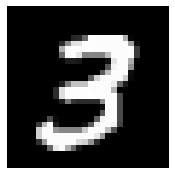

In [214]:
# =====================================================
# VISUALIZING A SAMPLE IMAGE
# =====================================================

# Let's look at the 8th image (index 7) - it's a nice "3"
im3 = x_imgs[7]

print(f"Image shape: {im3.shape}")
print(f"Pixel value range: {im3.min():.2f} to {im3.max():.2f}")
print(f"Label: {y_train[7]}")

# Display the image
show_image(im3)

## 🛠️ Interactive visualizations — one-time setup

The cells marked **🎮 Interactive** below embed standalone HTML/JS visualizations
(stored in the `interactive_viz/` folder next to this notebook) at **full width and
~full viewport height**. Run the next cell once, then run any 🎮 cell.

In [215]:
# ============================================================================
# INTERACTIVE VISUALIZATIONS -- setup (run this cell ONCE).
# Each "🎮 Interactive" cell below loads a standalone HTML file from the
# published copy on GitHub Pages, in an isolated <iframe> (its CSS/JS can't leak
# into the notebook). It is shown FULL WIDTH and auto-fits its content height.
# No local files needed -- the visualizations are read from GitHub.
# ============================================================================
from IPython.display import HTML

def show_viz(path, height="600px"):
    """Embed an interactive visualization full width; it auto-fits its height.
    `path` may be a bare 'interactive_viz/<file>.html' (resolved to the GitHub
    Pages copy) or a full https URL."""
    base = "https://shammun.github.io/shammunul-fastai-notes/notebooks/"
    if not path.startswith("http"):
        path = base + path
    return HTML(
        f'<iframe src="{path}" loading="lazy" allowfullscreen '
        f'style="width:100%;height:{height};border:1px solid #dde5f2;border-radius:12px;'
        f'box-shadow:0 8px 24px rgba(123,92,214,.12);background:#fff;"></iframe>'
        '<script>addEventListener("message",function(e){'
        'if(e.data&&e.data.type==="ce-frame-height"&&e.data.height>50){'
        'var fs=document.querySelectorAll("iframe");for(var i=0;i<fs.length;i++){'
        'if(fs[i].contentWindow===e.source){fs[i].style.height=e.data.height+"px";break;}}}});</script>'
    )


------------------------------------------------------------------------

# Part 2: What is a Convolution?

------------------------------------------------------------------------

## The Big Picture

A **convolution** is an operation that:

1.  Takes a small matrix called a **kernel** (or **filter**)
2.  Slides it across the image
3.  At each position, computes the **element-wise multiplication** and **sums** the results
4.  The output is a new image called a **feature map** or **activation map**

------------------------------------------------------------------------

### Visual Explanation

Imagine you have a 3×3 input image and a 2×2 kernel:

    Input Image (3×3):          Kernel (2×2):
    ┌───┬───┬───┐               ┌───┬───┐
    │ 1 │ 2 │ 3 │               │ 1 │ 0 │
    ├───┼───┼───┤               ├───┼───┤
    │ 4 │ 5 │ 6 │               │ 0 │ 1 │
    ├───┼───┼───┤               └───┴───┘
    │ 7 │ 8 │ 9 │
    └───┴───┴───┘

**Step 1:** Position kernel at top-left

    ┌───┬───┐───┐
    │ 1 │ 2 │ 3 │    1×1 + 2×0 + 4×0 + 5×1 = 1 + 0 + 0 + 5 = 6
    ├───┼───┤───┤
    │ 4 │ 5 │ 6 │
    └───┴───┴───┘

**Step 2:** Slide kernel right

    ┌───┬───┬───┐
    │ 1 │ 2 │ 3 │    2×1 + 3×0 + 5×0 + 6×1 = 2 + 0 + 0 + 6 = 8
    ├───┼───┼───┤
    │ 4 │ 5 │ 6 │
    └───┴───┴───┘

**Steps 3-4:** Slide down, repeat...

**Result (2×2):**

    ┌───┬───┐
    │ 6 │ 8 │
    ├───┼───┤
    │12 │14 │
    └───┴───┘

------------------------------------------------------------------------

### The Convolution Formula

For a 3×3 kernel, if we label the input pixels:

$$\begin{matrix} a_1 & a_2 & a_3 \ a_4 & a_5 & a_6 \ a_7 & a_8 & a_9 \end{matrix}$$

And the kernel weights:

$$\begin{matrix} k_1 & k_2 & k_3 \ k_4 & k_5 & k_6 \ k_7 & k_8 & k_9 \end{matrix}$$

The output is:

$$\text{output} = \sum_{i=1}^{9} a_i \cdot k_i = a_1 k_1 + a_2 k_2 + ... + a_9 k_9$$

This is just **element-wise multiplication followed by summation** - also known as a **dot product**!

------------------------------------------------------------------------

### A Worked Example (from the fastbook)

Here's the input — a small patch of pixel values:

<img alt="The image" width="75" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/att_00032.png">

Here's our kernel — the small weight matrix we slide over it:

<img alt="The kernel" width="55" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/att_00033.png">

Since the filter fits in the image four times, we get four output activations:

<img alt="The activations" width="52" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/att_00034.png">

Applying the kernel at one position — element-wise multiply, then sum:

<img alt="Applying the kernel" width="366" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/att_00035.png">

Written as an equation, a single output cell is just a weighted sum of the nine inputs:

<img alt="The equation" width="436" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/att_00036.png">

### 🎮 Interactive: slide a kernel over a digit — the formula, alive

The formula above is just three moves repeated everywhere. In this playground a 3×3 kernel slides over a 9×9 "7":

**What to try**
- Click the stage chips — **① place window → ② multiply → ③ sum & write** — each one highlights the matching line of code.
- **Click any output pixel** to jump the kernel straight to that position.
- Switch kernels (top edge / left edge / diagonal / blur / sharpen) or pick **custom** and edit any weight.
- Use ▶ Play with the speed slider, or step one move at a time.

In [216]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/conv_kernel_slide.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/conv_kernel_slide.html", height="700px")

------------------------------------------------------------------------

# Part 3: Edge Detection with Kernels

------------------------------------------------------------------------

## What Are Edges and Why Do They Matter?

In computer vision, **edges** are boundaries where pixel intensity changes sharply. Edges are important because:

- They define the **shape** of objects
- They're more **informative** than flat regions
- The digit "7" has a **horizontal edge** at the top and a **diagonal edge** going down

We can design kernels that **detect edges** by responding strongly to intensity changes.

------------------------------------------------------------------------

## The Top Edge Detector

Here's a kernel that detects **horizontal edges** (specifically, transitions from dark to light going downward):

In [217]:
# =====================================================
# TOP EDGE DETECTION KERNEL
# =====================================================

# This kernel detects horizontal edges (top edges of objects)
#
# How it works:
#   - Top row has -1s: penalizes bright pixels at top
#   - Middle row has 0s: ignores the middle
#   - Bottom row has +1s: rewards bright pixels at bottom
#
# When this kernel is placed over a horizontal edge
# (dark on top, light on bottom), the result is a large positive number.
# When placed over a uniform area, positive and negative cancel out.

top_edge = tensor([
    [-1, -1, -1],   # Top row: subtract these pixels
    [ 0,  0,  0],   # Middle: ignore
    [ 1,  1,  1]    # Bottom: add these pixels
]).float()          # .float() converts to float32 (needed for calculations)

print("Top edge detection kernel:")
print(top_edge)

Top edge detection kernel:
tensor([[-1., -1., -1.],
        [ 0.,  0.,  0.],
        [ 1.,  1.,  1.]])


**Why does this detect top edges?**

Consider what happens in different situations:

| Region Type               | Top pixels | Bottom pixels | Calculation | Result                 |
|---------------------------|------------|---------------|-------------|------------------------|
| Uniform dark (0s)         | 0, 0, 0    | 0, 0, 0       | 0 - 0       | **0** (no edge)        |
| Uniform bright (1s)       | 1, 1, 1    | 1, 1, 1       | 3 - 3       | **0** (no edge)        |
| Top edge (dark→bright)    | 0, 0, 0    | 1, 1, 1       | 3 - 0       | **+3** (strong edge!)  |
| Bottom edge (bright→dark) | 1, 1, 1    | 0, 0, 0       | 0 - 3       | **-3** (opposite edge) |

Text(0.5, 1.0, 'Top Edge Kernel\n(white=+1, black=-1, gray=0)')

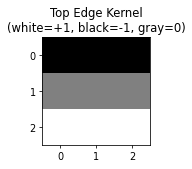

In [218]:
# Let's visualize the kernel
show_image(top_edge, noframe=False, figsize=(2,2))
plt.title("Top Edge Kernel\n(white=+1, black=-1, gray=0)")

------------------------------------------------------------------------

## Applying the Kernel Manually

Let's see exactly how convolution works by doing it step by step.

In [219]:
# =====================================================
# VIEWING THE IMAGE AS NUMBERS
# =====================================================

# Let's look at the actual pixel values in part of our image
# We'll create a DataFrame for nice display

# Take the top-left portion of the image (first 13 rows, first 23 columns)
df = pd.DataFrame(im3[:13, :23].numpy())

# Format: 2 decimal places, small font, color-coded by value
df.style.format(precision=2).set_properties(**{'font-size': '7pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.15,0.17,0.41,1.00,0.99,0.99,0.99,0.99,0.99,0.68,0.02,0.00
6,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.17,0.54,0.88,0.88,0.98,0.99,0.98,0.98,0.98,0.98,0.98,0.98,0.62,0.05
7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.70,0.98,0.98,0.98,0.98,0.99,0.98,0.98,0.98,0.98,0.98,0.98,0.98,0.23
8,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.43,0.98,0.98,0.90,0.52,0.52,0.52,0.52,0.74,0.98,0.98,0.98,0.98,0.23
9,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.11,0.11,0.09,0.00,0.00,0.00,0.00,0.05,0.88,0.98,0.98,0.67,0.03


**Reading the table above:**

- Black cells (value ~0) are dark (background)
- White cells (value ~1) are bright (the digit)
- You can see the "3" shape forming in the right side

Now let's apply our kernel to specific locations:

In [220]:
# =====================================================
# MANUAL CONVOLUTION - Example 1
# =====================================================

# Extract a 3x3 patch from the image
# Rows 3 to 5 (Python slicing: 3:6), Columns 14 to 16 (14:17)
patch1 = im3[3:6, 14:17]

print("Patch from image (rows 3-5, cols 14-16):")
print(patch1)
print()
print("Kernel:")
print(top_edge)
print()
print("Element-wise multiplication:")
print(patch1 * top_edge)
print()
print(f"Sum (the convolution output): {(patch1 * top_edge).sum():.4f}")

Patch from image (rows 3-5, cols 14-16):
tensor([[0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.9961, 0.9883, 0.9883]])

Kernel:
tensor([[-1., -1., -1.],
        [ 0.,  0.,  0.],
        [ 1.,  1.,  1.]])

Element-wise multiplication:
tensor([[-0.0000, -0.0000, -0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.9961, 0.9883, 0.9883]])

Sum (the convolution output): 2.9727


The result is close to 0 because this region is relatively uniform (all dark or no strong edge).

Let's try a region with a clear edge:

In [221]:
# =====================================================
# MANUAL CONVOLUTION - Example 2 (Finding an Edge)
# =====================================================

# Extract a 3x3 patch that should contain a top edge
# Rows 7 to 9, Columns 14 to 16
patch2 = im3[7:10, 14:17]

print("Patch from image (rows 7-9, cols 14-16):")
print(patch2)
print()
print("Notice: bottom row is brighter than top row - this is an edge!")
print()
print("Element-wise multiplication:")
print(patch2 * top_edge)
print()
print(f"Sum (the convolution output): {(patch2 * top_edge).sum():.4f}")

Patch from image (rows 7-9, cols 14-16):
tensor([[0.9883, 0.9844, 0.9844],
        [0.5195, 0.5156, 0.5156],
        [0.0000, 0.0000, 0.0000]])

Notice: bottom row is brighter than top row - this is an edge!

Element-wise multiplication:
tensor([[-0.9883, -0.9844, -0.9844],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000]])

Sum (the convolution output): -2.9570


**A larger positive value indicates a strong horizontal edge!**

Now let's create a function to make this easier:

In [222]:
# =====================================================
# FUNCTION TO APPLY KERNEL AT A SPECIFIC LOCATION
# =====================================================

def apply_kernel(row, col, kernel):
    """
    Apply a 3x3 kernel to the image at a specific (row, col) position.

    Arguments:
        row    - The center row of the 3x3 patch
        col    - The center column of the 3x3 patch
        kernel - A 3x3 tensor (the filter)

    Returns:
        The sum of element-wise multiplication (scalar value)

    How it works:
        - Extracts a 3x3 patch centered at (row, col)
        - Multiplies element-wise with the kernel
        - Returns the sum

    Note: The patch is from (row-1) to (row+1) inclusive, same for columns.
          Python slicing [row-1:row+2] gives us exactly 3 rows.
    """
    # Extract 3x3 patch: rows from row-1 to row+1, cols from col-1 to col+1
    patch = im3[row-1:row+2, col-1:col+2]

    # Element-wise multiply and sum
    return (patch * kernel).sum()

In [223]:
# Test the function
# This should give the same result as our manual calculation above
result = apply_kernel(8, 15, top_edge)  # Center at row 8, col 15
print(f"Kernel applied at position (8, 15): {result:.4f}")

Kernel applied at position (8, 15): -2.9570


------------------------------------------------------------------------

## Creating the Full Edge Map

Now let's apply the kernel to **every valid position** in the image to create an edge map.

**Important:** For a 28×28 image with a 3×3 kernel:

- We can't apply the kernel at the edges (no pixels to the left of column 0!)
- Valid positions: rows 1-26, columns 1-26 (center positions)
- Output size: 26×26

In [224]:
# =====================================================
# UNDERSTANDING LIST COMPREHENSIONS
# =====================================================

# Before we create the edge map, let's understand nested list comprehensions
#
# A list comprehension: [expression for variable in iterable]
# Nested: [[expression for j in range] for i in range]

# Example: Create a 5x5 grid of (row, col) coordinates
grid = [[(i, j) for j in range(5)] for i in range(5)]

print("5x5 coordinate grid:")
for row in grid:
    print(row)

5x5 coordinate grid:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)]
[(1, 0), (1, 1), (1, 2), (1, 3), (1, 4)]
[(2, 0), (2, 1), (2, 2), (2, 3), (2, 4)]
[(3, 0), (3, 1), (3, 2), (3, 3), (3, 4)]
[(4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]


In [225]:
# =====================================================
# CREATING THE TOP EDGE MAP
# =====================================================

# Range of valid center positions: 1 to 26 (inclusive)
# range(1, 27) gives [1, 2, 3, ..., 26]
rng = range(1, 27)

# Apply the kernel at every valid position using nested list comprehension
#
# For each row i from 1 to 26:
#   For each column j from 1 to 26:
#     Compute apply_kernel(i, j, top_edge)
#
# This creates a 26x26 list of lists, which we convert to a tensor

top_edge_map = tensor([[apply_kernel(i, j, top_edge) for j in rng] for i in rng])

print(f"Edge map shape: {top_edge_map.shape}")
print(f"Original image shape: {im3.shape}")
print(f"Note: Output is 2 pixels smaller in each dimension (28 - 2 = 26)")

Edge map shape: torch.Size([26, 26])
Original image shape: torch.Size([28, 28])
Note: Output is 2 pixels smaller in each dimension (28 - 2 = 26)


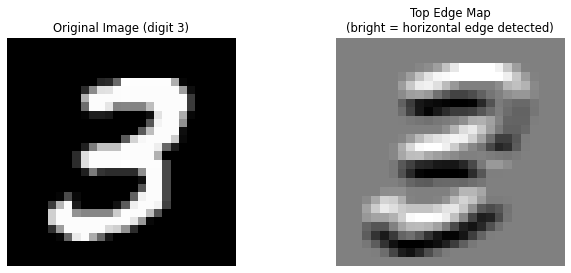

In [226]:
# =====================================================
# VISUALIZING THE TOP EDGE MAP
# =====================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

show_image(im3, ax=ax1)
ax1.set_title("Original Image (digit 3)")

show_image(top_edge_map, ax=ax2)
ax2.set_title("Top Edge Map\n(bright = horizontal edge detected)")

plt.tight_layout()

**Notice how:**

- The top edge map shows **bright spots** where the original image has **horizontal edges**
- The top curve of the "3" is highlighted
- Vertical lines (sides of the digit) are mostly invisible to this filter

------------------------------------------------------------------------

## The Left Edge Detector

Now let's create a kernel that detects **vertical edges** (left edges):

In [227]:
# =====================================================
# LEFT EDGE DETECTION KERNEL
# =====================================================

# This kernel detects vertical edges (left edges of objects)
#
# How it works:
#   - Left column has -1s: penalizes bright pixels on left
#   - Middle column has 0s: ignores the middle
#   - Right column has +1s: rewards bright pixels on right
#
# When this kernel is placed over a vertical edge
# (dark on left, light on right), the result is a large positive number.

left_edge = tensor([
    [-1, 0, 1],   # Top row
    [-1, 0, 1],   # Middle row
    [-1, 0, 1]    # Bottom row
]).float()

print("Left edge detection kernel:")
print(left_edge)

Left edge detection kernel:
tensor([[-1.,  0.,  1.],
        [-1.,  0.,  1.],
        [-1.,  0.,  1.]])


Text(0.5, 1.0, 'Left Edge Kernel')

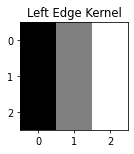

In [228]:
# Visualize the kernel
show_image(left_edge, noframe=False, figsize=(2,2))
plt.title("Left Edge Kernel")

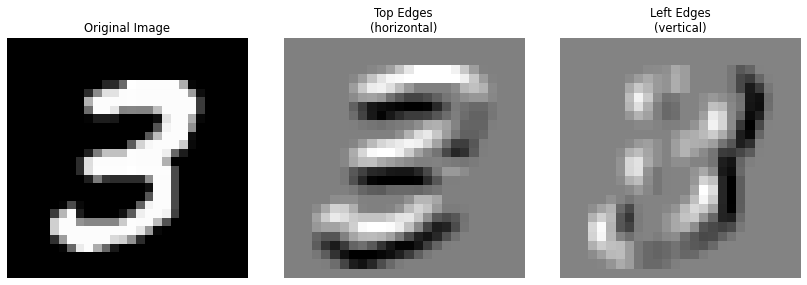

In [229]:
# =====================================================
# CREATING THE LEFT EDGE MAP
# =====================================================

left_edge_map = tensor([[apply_kernel(i, j, left_edge) for j in rng] for i in rng])

# Compare original, top edges, and left edges
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

show_image(im3, ax=ax1)
ax1.set_title("Original Image")

show_image(top_edge_map, ax=ax2)
ax2.set_title("Top Edges\n(horizontal)")

show_image(left_edge_map, ax=ax3)
ax3.set_title("Left Edges\n(vertical)")

plt.tight_layout()

**Compare the two edge maps:**

- **Top edges** highlight the curved parts of the "3" where the stroke goes horizontally
- **Left edges** highlight where the stroke goes vertically

Together, these would capture the full outline of the digit!

------------------------------------------------------------------------

### 🎮 Interactive: edge-detection lab — see *why* the kernel fires

You just saw top-edge and left-edge maps of the "3". This lab shows the **term-by-term arithmetic** behind each verdict:

**What to try**
- Walk the scenario chips: **uniform region → top edge → bottom edge → vertical edge** — watch which terms cancel and which survive.
- Open **⑤ draw your own**: paint any shape on the 16×16 canvas (Box / Seven presets too) and watch the edge map update **live** (teal = positive, red = negative).
- Switch kernels — including a custom editable one — and repaint.

In [230]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/edge_kernel_lab.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/edge_kernel_lab.html", height="760px")

------------------------------------------------------------------------

# Part 4: Convolutions in PyTorch

------------------------------------------------------------------------

Our manual convolution works, but it's **very slow**. For each position, we're doing Python loops, which are inefficient.

PyTorch provides highly optimized convolution operations that run on GPU and use efficient algorithms.

------------------------------------------------------------------------

## Understanding the im2col Algorithm

The key insight: convolution is just a bunch of dot products. If we **rearrange** the data cleverly, we can use matrix multiplication (which is extremely optimized on GPUs).

The technique is called **im2col** (image to column):

1.  Extract all the patches that the kernel will be applied to
2.  Flatten each patch into a column
3.  Stack all columns into a matrix
4.  Flatten the kernel into a row
5.  Matrix multiply: kernel_row @ patch_matrix

Let's see this in action:

### Visualizing the Convolution

Applying a kernel across a grid — the kernel slides over every position:

<img alt="Applying a kernel across a grid" width="400" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/chapter9_nopadconv.svg">

Here's the result of applying a 3×3 kernel to a 4×4 image (animation courtesy of Vincent Dumoulin and Francesco Visin):

<img alt="Result of applying a 3x3 kernel to a 4x4 image" width="782" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/att_00028.png">

**The im2col trick.** Rather than looping in Python, we lay every sliding window out as a *column* of a matrix; convolution then collapses into a single matrix multiply:

<img alt="im2col laid out as a matrix multiply" width="700" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/att_conv_cell38.png">

In [231]:
import torch.nn.functional as F
import torch

In [232]:
# =====================================================
# THE UNFOLD OPERATION (im2col in PyTorch)
# =====================================================

# F.unfold extracts all patches from an image
#
# First, we need to add batch and channel dimensions to our image
# PyTorch expects: (batch_size, channels, height, width)
#
# None adds a new dimension of size 1:
#   im3 shape:        (28, 28)
#   im3[None] shape:  (1, 28, 28)
#   im3[None, None]:  (1, 1, 28, 28)  <- batch=1, channels=1

inp = im3[None, None, :, :].float()  # Add batch and channel dims
print(f"Input shape: {inp.shape}")
print(f"  - Batch size: {inp.shape[0]}")
print(f"  - Channels: {inp.shape[1]}")
print(f"  - Height: {inp.shape[2]}")
print(f"  - Width: {inp.shape[3]}")

Input shape: torch.Size([1, 1, 28, 28])
  - Batch size: 1
  - Channels: 1
  - Height: 28
  - Width: 28


In [233]:
# =====================================================
# EXTRACTING ALL PATCHES WITH F.unfold
# =====================================================

# F.unfold(input, kernel_size) extracts all patches where the kernel fits
#
# For a 28x28 image with 3x3 kernel:
#   - 26x26 = 676 valid positions
#   - Each patch is 3x3 = 9 pixels
#
# Output shape: (batch, kernel_elements, num_patches)
#            = (1, 9, 676)

inp_unf = F.unfold(inp, (3, 3))  # Extract 3x3 patches
print(f"Unfolded shape: {inp_unf.shape}")

# Remove the batch dimension for easier math
inp_unf = inp_unf[0]
print(f"After removing batch dim: {inp_unf.shape}")
print(f"  - 9 = 3×3 pixels per patch")
print(f"  - 676 = 26×26 = number of patches")

Unfolded shape: torch.Size([1, 9, 676])
After removing batch dim: torch.Size([9, 676])
  - 9 = 3×3 pixels per patch
  - 676 = 26×26 = number of patches


In [234]:
# =====================================================
# FLATTEN THE KERNEL
# =====================================================

# Flatten the 3x3 kernel into a 1D vector of 9 elements
w = left_edge.view(-1)  # -1 means "flatten to 1D"
print(f"Kernel shape: {left_edge.shape} -> Flattened: {w.shape}")
print(f"Kernel values: {w}")

Kernel shape: torch.Size([3, 3]) -> Flattened: torch.Size([9])
Kernel values: tensor([-1.,  0.,  1., -1.,  0.,  1., -1.,  0.,  1.])


In [235]:
# =====================================================
# CONVOLUTION AS MATRIX MULTIPLICATION
# =====================================================

# Now we can compute all convolutions with a single matrix multiplication!
#
# w @ inp_unf:
#   w shape:       (9,)
#   inp_unf shape: (9, 676)
#   output shape:  (676,)  <- one output for each patch
#
# The @ operator is matrix/vector multiplication

out_unf = w @ inp_unf
print(f"Output shape (flattened): {out_unf.shape}")

Output shape (flattened): torch.Size([676])


Output image shape: torch.Size([26, 26])


<Axes: >

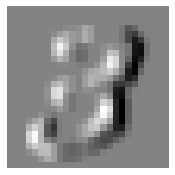

In [236]:
# =====================================================
# RESHAPE BACK TO 2D IMAGE
# =====================================================

# Reshape the flat output back to a 26x26 image
out = out_unf.view(26, 26)
print(f"Output image shape: {out.shape}")

# Display it - should match our manual result!
show_image(out)

### 🎮 Interactive: im2col / `unfold` — convolution as ONE matrix multiply

This is the exact trick the cells above performed: sliding windows become **columns of a matrix**, the kernel becomes a **row**, and convolution collapses into a single matmul.

**What to try**
- Step the stages: **① `F.unfold` (patches fly into columns) → ② `kernel.view(1, 9)` → ③ matmul → ④ reshape to 4×4**.
- **Click any column** of the patch matrix — it highlights the source window in the input *and* its output pixel.
- Click any output pixel to trace it back the other way.

In [237]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/im2col_unfold.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/im2col_unfold.html", height="700px")

**This is exactly the same as our manual convolution, but much faster!**

------------------------------------------------------------------------

## Using F.conv2d - The Easy Way

PyTorch's `F.conv2d` does all of this (and more optimizations) automatically:

Kernel shape for conv2d: torch.Size([1, 1, 3, 3])
Output shape: torch.Size([1, 1, 26, 26])


<Axes: >

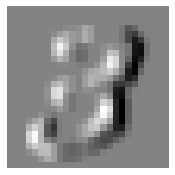

In [238]:
# =====================================================
# PYTORCH'S BUILT-IN CONVOLUTION
# =====================================================

# F.conv2d(input, weight) performs 2D convolution
#
# Input shape:  (batch, in_channels, height, width)
# Weight shape: (out_channels, in_channels, kernel_h, kernel_w)
#
# Our kernel is 3x3, but we need to add dimensions:
#   left_edge shape: (3, 3)
#   left_edge[None, None] shape: (1, 1, 3, 3)  <- 1 output channel, 1 input channel

# Prepare the kernel
kernel = left_edge[None, None]  # Add output_channel and input_channel dims
print(f"Kernel shape for conv2d: {kernel.shape}")

# Apply convolution
output = F.conv2d(inp, kernel)
print(f"Output shape: {output.shape}")

# Display (remove batch and channel dims for visualization)
show_image(output[0, 0])

------------------------------------------------------------------------

## Speed Comparison

Let's see how much faster the PyTorch operations are:

In [239]:
# Speed comparison (run each multiple times for reliable measurement)
import time

# Method 1: Manual Python loops
start = time.time()
for _ in range(1):
    manual = tensor([[apply_kernel(i, j, left_edge) for j in rng] for i in rng])
manual_time = time.time() - start

# Method 2: Unfold + matrix multiply
start = time.time()
for _ in range(100):
    unfold_result = (w @ F.unfold(inp, (3,3))[0]).view(26, 26)
unfold_time = (time.time() - start) / 100

# Method 3: F.conv2d
start = time.time()
for _ in range(100):
    conv_result = F.conv2d(inp, left_edge[None, None])
conv_time = (time.time() - start) / 100

print(f"Manual loops:    {manual_time*1000:.2f} ms")
print(f"Unfold + matmul: {unfold_time*1000:.4f} ms  ({manual_time/unfold_time:.0f}x faster)")
print(f"F.conv2d:        {conv_time*1000:.4f} ms  ({manual_time/conv_time:.0f}x faster)")

Manual loops:    16.25 ms
Unfold + matmul: 0.0568 ms  (286x faster)
F.conv2d:        0.0204 ms  (796x faster)


**PyTorch's optimized operations are hundreds or thousands of times faster!**

------------------------------------------------------------------------

------------------------------------------------------------------------

## Multiple Kernels at Once

In practice, we use **many kernels** to detect different features. PyTorch can apply all of them in a single operation.

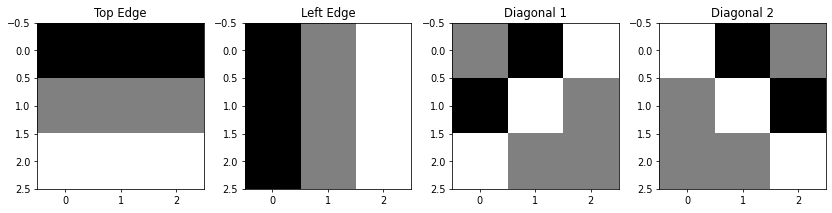

In [240]:
# =====================================================
# DIAGONAL EDGE KERNELS
# =====================================================

# Diagonal kernel 1: detects edges going from top-right to bottom-left
diag1_edge = tensor([
    [ 0, -1,  1],
    [-1,  1,  0],
    [ 1,  0,  0]
]).float()

# Diagonal kernel 2: detects edges going from top-left to bottom-right
diag2_edge = tensor([
    [ 1, -1,  0],
    [ 0,  1, -1],
    [ 0,  0,  1]
]).float()

# Visualize all four kernels
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, kernel, name in zip(axes,
                            [top_edge, left_edge, diag1_edge, diag2_edge],
                            ['Top Edge', 'Left Edge', 'Diagonal 1', 'Diagonal 2']):
    show_image(kernel, ax=ax, noframe=False)
    ax.set_title(name)
plt.tight_layout()

In [241]:
# =====================================================
# APPLYING MULTIPLE KERNELS TO A BATCH OF IMAGES
# =====================================================

# Prepare a batch of 16 images
# Shape: (16, 1, 28, 28) - 16 images, 1 channel each
xb = x_imgs[:16][:, None]  # Add channel dimension
print(f"Batch shape: {xb.shape}")

# Stack all 4 kernels together
# Each kernel is (3, 3), we need (out_channels, in_channels, H, W)
# So we stack them and add the in_channels dimension
edge_kernels = torch.stack([left_edge, top_edge, diag1_edge, diag2_edge])
print(f"Stacked kernels: {edge_kernels.shape}")

edge_kernels = edge_kernels[:, None]  # Add in_channels dimension
print(f"Final kernel shape: {edge_kernels.shape}")
print(f"  - 4 output channels (one per kernel)")
print(f"  - 1 input channel")
print(f"  - 3x3 kernel size")

Batch shape: torch.Size([16, 1, 28, 28])
Stacked kernels: torch.Size([4, 3, 3])
Final kernel shape: torch.Size([4, 1, 3, 3])
  - 4 output channels (one per kernel)
  - 1 input channel
  - 3x3 kernel size


In [242]:
# =====================================================
# BATCH CONVOLUTION
# =====================================================

# Apply all 4 kernels to all 16 images at once!
batch_features = F.conv2d(xb, edge_kernels)

print(f"Output shape: {batch_features.shape}")
print(f"  - 16 images")
print(f"  - 4 feature maps per image (one per kernel)")
print(f"  - 26x26 pixels each (28 - 3 + 1 = 26)")

Output shape: torch.Size([16, 4, 26, 26])
  - 16 images
  - 4 feature maps per image (one per kernel)
  - 26x26 pixels each (28 - 3 + 1 = 26)


In [243]:
xb.shape

torch.Size([16, 1, 28, 28])

# Understanding the Extra Dimension of `1` in `conv2d`

## What this section clarifies

We just saw two tensors with a puzzling extra `1` in their shapes:

- `xb.shape` → `(16, 1, 28, 28)`
- `edge_kernels.shape` → `(4, 1, 3, 3)`

**The confusion:** *Why is there an extra dimension of `1` in both the batch of images and the stacked kernels, and how is that helpful?*

The short answer: both `1`s are the **channel dimension**, and they exist so that `F.conv2d` can correctly match the input's channels to each kernel's channels.

---

## The fixed 4D layout `conv2d` requires

`F.conv2d` always expects a specific 4D layout for both arguments:

- **Input:** `(batch, in_channels, H, W)`
- **Weight (kernels):** `(out_channels, in_channels, H, W)`

Every axis must be present, even when its size is just `1`.

### The `1` in `xb` → `(16, 1, 28, 28)`

MNIST images are **grayscale**, so they have exactly **one input channel**. A color image would have 3 channels (RGB).

The convolution operation always needs a channel axis to slide kernels over, even when there is only one channel. Without it, the tensor would be `(16, 28, 28)`, which `conv2d` cannot interpret unambiguously.

### The `1` in `edge_kernels` → `(4, 1, 3, 3)`

This `1` is the kernel's **`in_channels`**, and it **must match** the input's `in_channels` (both are `1` here).

The rule is that **each kernel spans all input channels**: a single kernel has shape `(in_channels, H, W)`, and you stack `out_channels` of them. Since our input has only 1 channel, each kernel only needs to cover that 1 channel.

---

## How the dimensions connect

```
input:   (16,  1, 28, 28)
              │
              └── must match ──┐
                               │
weight:  ( 4,  1,  3,  3)
          │
          └── becomes output channels

output:  (16,  4, 26, 26)
```

- `in_channels` of the input (`1`) **must equal** `in_channels` of the weight (`1`).
- `out_channels` of the weight (`4`, our four edge kernels) **becomes** the channel count of the output.
- Each of the 16 images now carries 4 feature maps, one per kernel.

---

## Why this design is helpful

The channel dimension is what makes conv layers **composable**.

The 4 output channels here can become the **input channels of the next conv layer**, whose kernels would then have shape `(next_out, 4, 3, 3)`. Stacking convs this way — each layer's `out_channels` feeding the next layer's `in_channels` — is exactly how deep CNNs build up from simple edge detectors to complex features. The single-channel case is just the degenerate starting point.

---

## Quick rule of thumb

> In `conv2d`, the **second** dimension of the input and the **second** dimension of the weight must always be equal.

That second dimension is `in_channels` in both cases.

In [244]:
batch_features[0,0].shape

torch.Size([26, 26])

Original image (label: 0):


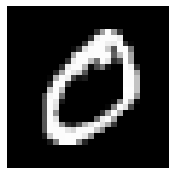

Edge feature maps:


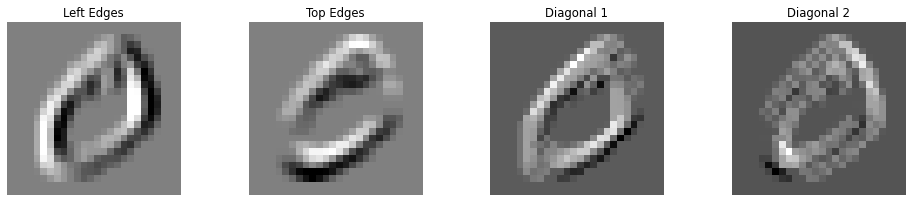

In [245]:
# =====================================================
# VISUALIZING THE FEATURE MAPS
# =====================================================

# Let's look at one image and its 4 feature maps
img_idx = 1  # Second image in batch

# Original image
print(f"Original image (label: {y_train[img_idx]}):")
show_image(xb[img_idx, 0])
plt.show()

# All 4 edge maps
print("Edge feature maps:")
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
titles = ['Left Edges', 'Top Edges', 'Diagonal 1', 'Diagonal 2']
for i, (ax, title) in enumerate(zip(axes, titles)):
    show_image(batch_features[img_idx, i], ax=ax)
    ax.set_title(title)
plt.tight_layout()

**Each kernel detects different features!**

- Horizontal edges show where the stroke goes left-right
- Vertical edges show where it goes up-down
- Diagonal edges show the angled parts

Together, these give a rich representation of the digit's shape.

------------------------------------------------------------------------

------------------------------------------------------------------------

# Part 5: Strides and Padding

------------------------------------------------------------------------

## The Size Problem

We've seen that a 28×28 image with a 3×3 kernel produces a 26×26 output. This **shrinkage** is a problem:

- After several layers, the image becomes tiny
- We lose information at the edges

**Two concepts help control output size:**

1.  **Padding** - Add zeros around the edges to maintain size
2.  **Stride** - Skip positions to reduce size intentionally

------------------------------------------------------------------------

## Padding

**Padding** adds extra pixels (usually zeros) around the border of the image.

    Original 3x3:          With padding=1 (5x5):
    ┌───┬───┬───┐          ┌───┬───┬───┬───┬───┐
    │ 1 │ 2 │ 3 │          │ 0 │ 0 │ 0 │ 0 │ 0 │
    ├───┼───┼───┤          ├───┼───┼───┼───┼───┤
    │ 4 │ 5 │ 6 │   -->    │ 0 │ 1 │ 2 │ 3 │ 0 │
    ├───┼───┼───┤          ├───┼───┼───┼───┼───┤
    │ 7 │ 8 │ 9 │          │ 0 │ 4 │ 5 │ 6 │ 0 │
    └───┴───┴───┘          ├───┼───┼───┼───┼───┤
                           │ 0 │ 7 │ 8 │ 9 │ 0 │
                           ├───┼───┼───┼───┼───┤
                           │ 0 │ 0 │ 0 │ 0 │ 0 │
                           └───┴───┴───┴───┴───┘

**Magic formula for same-size output:**

- For a kernel of size `ks × ks` (where `ks` is odd)
- Use padding = `ks // 2`
- Example: 3×3 kernel → padding = 1, 5×5 kernel → padding = 2

------------------------------------------------------------------------

## Stride

**Stride** is how many pixels we move the kernel each step.

- **Stride 1** (default): Move one pixel at a time, output is similar size to input
- **Stride 2**: Move two pixels at a time, output is half the size
- **Stride 4**: Move four pixels at a time, output is quarter the size

**Stride 2 is commonly used** in CNNs to reduce image size (instead of pooling).

    5x5 input, 3x3 kernel, stride 2:

    Position 1:    Position 2:    Position 3:    Position 4:
    ┌───┬───┬───┐  ┌───┬───┬───┐  ┌───┬───┬───┐  ┌───┬───┬───┐
    │ X │ X │ X │  │   │   │ X │  │ X │ X │ X │  │   │   │ X │
    ├───┼───┼───┤  ├───┼───┼───┤  ├───┼───┼───┤  ├───┼───┼───┤
    │ X │ X │ X │  │   │   │ X │  │   │   │   │  │   │   │   │
    ├───┼───┼───┤  ├───┼───┼───┤  ├───┼───┼───┤  ├───┼───┼───┤
    │ X │ X │ X │  │   │   │ X │  │ X │ X │ X │  │   │   │ X │
    └───┴───┴───┘  └───┴───┴───┘  ├───┼───┼───┤  ├───┼───┼───┤
                                  │ X │ X │ X │  │   │   │ X │
                                  ├───┼───┼───┤  ├───┼───┼───┤
                                  │ X │ X │ X │  │   │   │ X │
                                  └───┴───┴───┘  └───┴───┴───┘

    Output is 2x2 (roughly half in each dimension)

------------------------------------------------------------------------

### Padding and Stride, Visually

With appropriate padding we can keep the output the same size as the input:

<img alt="A convolution with padding" width="600" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/chapter9_padconv.svg">

A 4×4 kernel with a 5×5 input and 2 pixels of padding gives a 6×6 activation map (courtesy of Vincent Dumoulin and Francesco Visin):

<img alt="A 4x4 kernel with 5x5 input and 2 pixels of padding" width="783" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/att_00029.png">

A *stride-2* convolution — a 3×3 kernel on a 5×5 input with 1 pixel of padding — moves two pixels at a time, roughly halving the output:

<img alt="A 3x3 kernel with 5x5 input, stride-2, and 1 pixel of padding" width="774" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/att_00030.png">

## Output Size Formula

For input size `n`, kernel size `k`, padding `p`, and stride `s`:

$$\text{output size} = \lfloor \frac{n + 2p - k}{s} \rfloor + 1$$

**Common cases:**

| Input | Kernel | Padding | Stride | Output | Notes                      |
|-------|--------|---------|--------|--------|----------------------------|
| 28    | 3      | 0       | 1      | 26     | Shrinks by kernel-1        |
| 28    | 3      | 1       | 1      | 28     | Same size (padding = k//2) |
| 28    | 3      | 1       | 2      | 14     | Half size (stride 2)       |
| 14    | 3      | 1       | 2      | 7      | Half again                 |
| 7     | 3      | 1       | 2      | 4      | And again...               |

------------------------------------------------------------------------

### 🎮 Interactive: stride & padding playground — the output-size formula, live

Don't memorize $\lfloor (n + 2p - k)/s \rfloor + 1$ — *drive* it:

**What to try**
- Drag the **n / k / p / s** sliders and watch the formula recompute with your numbers plugged in.
- Try the preset chips: **valid** (p=0, s=1), **same** (p=k//2), **halve** (s=2) and the 5×5 kernel case.
- Watch for the ⚠️ badge when the floor **drops leftover pixels** — now you know where "off-by-one" output sizes come from.
- Click any output cell to see exactly which input window produced it (padding cells are striped).

In [246]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/stride_padding_playground.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/stride_padding_playground.html")

------------------------------------------------------------------------

# Part 6: Building a CNN

------------------------------------------------------------------------

Now let's put everything together and build a **Convolutional Neural Network** for classifying MNIST digits!

## CNN Architecture Overview

A typical CNN has:

1.  **Convolutional layers** - Extract features using learned kernels
2.  **Activation functions** (ReLU) - Add non-linearity
3.  **Downsampling** (stride 2 or pooling) - Reduce spatial size
4.  **Final layer** - Map features to class predictions

------------------------------------------------------------------------

In [247]:
# =====================================================
# DATA PREPARATION
# =====================================================

# Get data dimensions
n, m = x_train.shape      # n = number of samples, m = number of features
c = y_train.max() + 1     # c = number of classes (0-9 = 10 classes)

print(f"Training samples: {n}")
print(f"Features per sample: {m}")
print(f"Number of classes: {c}")

nh = 50

Training samples: 50000
Features per sample: 784
Number of classes: 10


In [248]:
model = nn.Sequential(
    nn.Linear(m, nh), # number of pixels to the number of hidden neurons
    nn.ReLU(), # ReLU
    nn.Linear(nh, 10) # number of hidden neurons to the number of classes
) # Previously for our MLP models

### A First (Broken) Attempt

Let's try building a simple CNN and see what problems arise:

In [249]:
# =====================================================
# A "BROKEN" CNN - TO ILLUSTRATE THE PROBLEM
# =====================================================

# nn.Conv2d(in_channels, out_channels, kernel_size, padding)
#
# This network:
#   - Takes 1-channel input (grayscale)
#   - First conv: 1 -> 30 channels, 3x3 kernel, padding=1 (same size)
#   - ReLU activation
#   - Second conv: 30 -> 10 channels (one per digit class)

broken_cnn = nn.Sequential(
    nn.Conv2d(1, 30, kernel_size=3, padding=1),   # 28x28 -> 28x28, 30 channels
    nn.ReLU(),
    nn.Conv2d(30, 10, kernel_size=3, padding=1)   # 28x28 -> 28x28, 10 channels
)

In [250]:
# Let's see what output shape we get
output = broken_cnn(xb.float())
print(f"Input shape:  {xb.shape}")
print(f"Output shape: {output.shape}")

Input shape:  torch.Size([16, 1, 28, 28])
Output shape: torch.Size([16, 10, 28, 28])


**Problem:** The output is (16, 10, 28, 28), but we need (16, 10) for classification!

We have a 28×28 grid of predictions for each of 10 classes. We need to:

1.  Reduce the spatial dimensions to 1×1
2.  Flatten to get a single prediction per class

------------------------------------------------------------------------

### The Solution: Stride-2 Convolutions

We can use **stride-2 convolutions** to progressively reduce the image size:

In [251]:
# =====================================================
# HELPER FUNCTION: CREATE CONV LAYER WITH ReLU
# =====================================================

def conv(ni, nf, ks=3, stride=2, act=True):
    """
    Create a convolution layer with optional ReLU activation.

    Arguments:
        ni     - Number of input channels
        nf     - Number of output channels (filters)
        ks     - Kernel size (default 3 for 3x3)
        stride - Stride (default 2 to halve spatial size)
        act    - Whether to add ReLU activation (default True)

    Returns:
        A Conv2d layer, optionally wrapped with ReLU in a Sequential

    Notes:
        - padding=ks//2 ensures output size = input size / stride
        - For ks=3, padding=1
        - With stride=2, each layer halves the spatial dimensions
    """
    # Create the convolution layer
    res = nn.Conv2d(ni, nf, stride=stride, kernel_size=ks, padding=ks//2)

    # Optionally wrap with ReLU
    if act:
        res = nn.Sequential(res, nn.ReLU())

    return res

**Why create this helper function?**

1.  **Less error-prone** - No need to calculate padding each time
2.  **Cleaner code** - The CNN definition becomes easy to read
3.  **Consistent patterns** - All layers use the same conventions
4.  **Easy to modify** - Change one place to affect all layers

In [252]:
# =====================================================
# A SIMPLE CNN THAT WORKS!
# =====================================================

# The key insight: use stride=2 to halve the image size at each layer
#
# Starting with 28x28:
#   28 -> 14 -> 7 -> 4 -> 2 -> 1
#
# At 1x1, we can flatten to get one value per channel

simple_cnn = nn.Sequential(
    conv(1, 4),              # 28x28 input image -> 14x14 feature map, 4 channels  -- start with 1 channel and end with 4 channels
    conv(4, 8),              # 14x14  -> 7x7 feature map,   8 channels
    conv(8, 16),             # 7x7   -> 4x4 feature map,   16 channels
    conv(16, 16),            # 4x4   -> 2x2 feature map,   16 channels
    conv(16, 10, act=False), # 2x2   -> 1x1 feature map,   10 channels (no ReLU on final layer!)
    nn.Flatten(),            # (batch, 10, 1, 1) -> (batch, 10) -- remove unneccessary dimensions
)

print("Simple CNN architecture:")
print(simple_cnn)

Simple CNN architecture:
Sequential(
  (0): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
  )
  (1): Sequential(
    (0): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
  )
  (2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
  )
  (3): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
  )
  (4): Conv2d(16, 10, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (5): Flatten(start_dim=1, end_dim=-1)
)


#### How Does Each `conv` Layer Halve the Feature Map in `simple_cnn`?

#### The Question

In the following CNN, each layer halves the spatial dimensions: 28→14→7→4→2→1. How does this halving happen at every layer? Is there a hidden MaxPool somewhere?

    simple_cnn = nn.Sequential(
        conv(1, 4),              # 28x28 -> 14x14,  4 channels
        conv(4, 8),              # 14x14 -> 7x7,    8 channels
        conv(8, 16),             # 7x7   -> 4x4,   16 channels
        conv(16, 16),            # 4x4   -> 2x2,   16 channels
        conv(16, 10, act=False), # 2x2   -> 1x1,   10 channels
        nn.Flatten(),            # (batch, 10, 1, 1) -> (batch, 10)
    )

#### The Answer: It's All `stride=2` — No MaxPool

There is **no pooling layer** anywhere in this network. The halving at every layer comes from `stride=2`, which is baked into the `conv` helper function as a **default parameter**:

    def conv(ni, nf, ks=3, stride=2, act=True):
        res = nn.Conv2d(ni, nf, stride=stride, kernel_size=ks, padding=ks//2)
        if act:
            res = nn.Sequential(res, nn.ReLU())
        return res

So every call like `conv(1, 4)` or `conv(4, 8)` — where `stride` is not explicitly passed — automatically uses `stride=2`. This means the convolution kernel **jumps 2 pixels at a time** instead of 1, cutting the output size in half in each spatial dimension.

The other crucial default is `padding=ks//2 = 1`, which pads the input with a 1-pixel border of zeros. This ensures the halving works out cleanly without losing edge pixels.

#### Layer-by-Layer Walkthrough

The output size formula is:

$$\text{output} = \left\lfloor \frac{\text{input} + 2 \times \text{padding} - \text{kernel\size}}{\text{stride}} \right\rfloor + 1$$

With our defaults (`ks=3`, `padding=1`, `stride=2`), let's trace each layer:

#### Layer 1: `conv(1, 4)` — 28×28 → 14×14

$$\left\lfloor \frac{28 + 2(1) - 3}{2} \right\rfloor + 1 = \left\lfloor \frac{27}{2} \right\rfloor + 1 = 13 + 1 = \mathbf{14}$$

The single grayscale channel (1) is expanded into 4 feature maps, each 14×14.

#### Layer 2: `conv(4, 8)` — 14×14 → 7×7

$$\left\lfloor \frac{14 + 2(1) - 3}{2} \right\rfloor + 1 = \left\lfloor \frac{13}{2} \right\rfloor + 1 = 6 + 1 = \mathbf{7}$$

The 4 channels become 8, and each feature map shrinks from 14×14 to 7×7.

#### Layer 3: `conv(8, 16)` — 7×7 → 4×4

$$\left\lfloor \frac{7 + 2(1) - 3}{2} \right\rfloor + 1 = \left\lfloor \frac{6}{2} \right\rfloor + 1 = 3 + 1 = \mathbf{4}$$

8 channels become 16. Note that 7/2 = 3.5, but the floor operation rounds down, giving us 4×4.

#### Layer 4: `conv(16, 16)` — 4×4 → 2×2

$$\left\lfloor \frac{4 + 2(1) - 3}{2} \right\rfloor + 1 = \left\lfloor \frac{3}{2} \right\rfloor + 1 = 1 + 1 = \mathbf{2}$$

Channel count stays at 16, but spatial size halves again to 2×2.

#### Layer 5: `conv(16, 10, act=False)` — 2×2 → 1×1

$$\left\lfloor \frac{2 + 2(1) - 3}{2} \right\rfloor + 1 = \left\lfloor \frac{1}{2} \right\rfloor + 1 = 0 + 1 = \mathbf{1}$$

This final conv compresses everything to a 1×1 spatial map with 10 channels (one per digit class). `act=False` skips ReLU because this is the output layer — we need raw logits for the loss function.

#### Final: `nn.Flatten()` — Reshape for Classification

The tensor shape at this point is `(batch, 10, 1, 1)`. Flatten removes the trivial 1×1 spatial dimensions, giving `(batch, 10)` — exactly what we need for computing cross-entropy loss against 10 digit classes.

#### Summary Table

| Layer                     | What It Creates                         | Input Shape | Output Shape | What Changes               |
|---------------------------|-----------------------------------------|-------------|--------------|----------------------------|
| `conv(1, 4)`              | `Conv2d(1,4,3,stride=2,pad=1) + ReLU`   | 1 × 28 × 28 | 4 × 14 × 14  | Channels: 1→4, Space: ÷2   |
| `conv(4, 8)`              | `Conv2d(4,8,3,stride=2,pad=1) + ReLU`   | 4 × 14 × 14 | 8 × 7 × 7    | Channels: 4→8, Space: ÷2   |
| `conv(8, 16)`             | `Conv2d(8,16,3,stride=2,pad=1) + ReLU`  | 8 × 7 × 7   | 16 × 4 × 4   | Channels: 8→16, Space: ÷2  |
| `conv(16, 16)`            | `Conv2d(16,16,3,stride=2,pad=1) + ReLU` | 16 × 4 × 4  | 16 × 2 × 2   | Channels: same, Space: ÷2  |
| `conv(16, 10, act=False)` | `Conv2d(16,10,3,stride=2,pad=1)`        | 16 × 2 × 2  | 10 × 1 × 1   | Channels: 16→10, Space: ÷2 |
| `nn.Flatten()`            | —                                       | 10 × 1 × 1  | 10           | Remove spatial dims        |

#### The Design Pattern

The architecture follows a common CNN design principle: as spatial dimensions shrink (÷2 each layer), the number of channels grows (roughly ×2 each layer). This means information isn't lost — it's **traded from spatial resolution into channel depth**. The network starts by seeing a large image with few features, and ends with a tiny spatial map but many rich, abstract feature channels.

> **Key Takeaway:** Every `conv(ni, nf)` call in this notebook uses `stride=2` by default — no MaxPool is needed. The convolution itself handles both feature extraction *and* downsampling in a single learned operation.

In [253]:
# Verify the output shape
output = simple_cnn(xb.float())
print(f"Input shape:  {xb.shape}")
print(f"Output shape: {output.shape}")
print(f"\nPerfect! We get 10 values per image (one for each digit class)")

Input shape:  torch.Size([16, 1, 28, 28])
Output shape: torch.Size([16, 10])

Perfect! We get 10 values per image (one for each digit class)


**Let's trace through the shapes:**

| Layer        | Input Shape     | Output Shape    | Notes                |
|--------------|-----------------|-----------------|----------------------|
| Input        | -              | (16, 1, 28, 28) | 16 images, 1 channel |
| conv(1, 4)   | (16, 1, 28, 28) | (16, 4, 14, 14) | Stride 2 halves size |
| conv(4, 8)   | (16, 4, 14, 14) | (16, 8, 7, 7)   |                      |
| conv(8, 16)  | (16, 8, 7, 7)   | (16, 16, 4, 4)  |                      |
| conv(16, 16) | (16, 16, 4, 4)  | (16, 16, 2, 2)  |                      |
| conv(16, 10) | (16, 16, 2, 2)  | (16, 10, 1, 1)  | Final conv           |
| Flatten      | (16, 10, 1, 1)  | (16, 10)        | Remove spatial dims  |

------------------------------------------------------------------------

### 🎮 Interactive: inside `simple_cnn` — 28×28 pixels → 10 numbers

The shape table above, as a clickable machine:

**What to try**
- **Click any volume** (or its chip) to see that layer's code line, its shape math (28→14→7→4→2→1), its parameter count, and *why it's there*.
- ▶ Play the forward pass to watch the image shrink while channels grow.
- Click the **parameter bar** at the bottom — see where the 30,154 parameters actually live (hint: mostly the deep layers).

In [254]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/cnn_architecture_explorer.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/cnn_architecture_explorer.html", height="710px")

## Training the CNN

Now let's train our CNN on MNIST!

In [255]:
# =====================================================
# PREPARE DATA FOR TRAINING
# =====================================================

# Reshape images to (N, C, H, W) format for conv layers
x_imgs = x_train.view(-1, 1, 28, 28)   # Add channel dimension
xv_imgs = x_valid.view(-1, 1, 28, 28)

print(f"Training images shape: {x_imgs.shape}")
print(f"Validation images shape: {xv_imgs.shape}")

Training images shape: torch.Size([50000, 1, 28, 28])
Validation images shape: torch.Size([10000, 1, 28, 28])


In [256]:
# =====================================================
# DEVICE SELECTION (GPU IF AVAILABLE)
# =====================================================

# Choose the best available device
# MPS = Apple Silicon GPU, CUDA = NVIDIA GPU, else CPU

if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

print(f"Using device: {device}")

Using device: cpu


In [257]:
# =====================================================
# SIMPLE DATASET CLASS
# =====================================================

class Dataset:
    """
    A simple dataset that pairs inputs (x) with labels (y).

    Required for PyTorch's DataLoader.
    """
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        return self.x[i], self.y[i]

# Create datasets
train_ds = Dataset(x_imgs, y_train)
valid_ds = Dataset(xv_imgs, y_valid)

In [258]:
def get_dls(train_ds, valid_ds, bs, **kwargs):
    return (DataLoader(train_ds, batch_size=bs, shuffle=True, **kwargs),
            DataLoader(valid_ds, batch_size=bs*2, **kwargs))

In [259]:
# =====================================================
# DATA LOADERS WITH DEVICE TRANSFER
# =====================================================

def to_device(x, device=device):
    """Move a tensor or collection of tensors to the device."""
    if isinstance(x, torch.Tensor):
        return x.to(device)
    if isinstance(x, dict):
        return {k: v.to(device) for k, v in x.items()}
    return type(x)(to_device(o, device) for o in x)

def collate_device(batch):
    """Collate function that moves data to device."""
    from torch.utils.data import default_collate
    return to_device(default_collate(batch))

# Training hyperparameters
bs = 256    # Batch size
lr = 0.4    # Learning rate

# Create data loaders
# train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, collate_fn=collate_device)
# valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, collate_fn=collate_device)

print(f"Batch size: {bs}")
print(f"Training batches: {len(train_dl)}")
print(f"Validation batches: {len(valid_dl)}")

train_dl,valid_dl = get_dls(train_ds, valid_ds, bs, collate_fn=collate_device)

Batch size: 256
Training batches: 196
Validation batches: 20


In [260]:
# =====================================================
# TRAINING AND VALIDATION FUNCTIONS
# =====================================================

def accuracy(preds, targets):
    """Calculate accuracy: fraction of correct predictions."""
    return (preds.argmax(dim=1) == targets).float().mean()

def train_epoch(model, loss_func, opt, train_dl):
    """Train for one epoch."""
    model.train()  # Set to training mode
    for xb, yb in train_dl:
        # Forward pass
        preds = model(xb)
        loss = loss_func(preds, yb)

        # Backward pass
        loss.backward()
        opt.step()
        opt.zero_grad()

def validate(model, loss_func, valid_dl):
    """Calculate validation loss and accuracy."""
    model.eval()  # Set to evaluation mode
    with torch.no_grad():
        losses, accs, counts = [], [], []
        for xb, yb in valid_dl:
            preds = model(xb)
            losses.append(loss_func(preds, yb) * len(xb))
            accs.append(accuracy(preds, yb) * len(xb))
            counts.append(len(xb))

        total = sum(counts)
        return sum(losses)/total, sum(accs)/total

def fit(epochs, model, loss_func, opt, train_dl, valid_dl):
    """Train for multiple epochs and track progress."""
    for epoch in range(epochs):
        train_epoch(model, loss_func, opt, train_dl)
        loss, acc = validate(model, loss_func, valid_dl)
        print(f"Epoch {epoch+1}: loss={loss:.4f}, accuracy={acc:.4f}")
    return loss, acc

In [261]:
def_device = device

In [262]:
# =====================================================
# TRAIN THE CNN!
# =====================================================

# Re-create the model (fresh weights)
simple_cnn = nn.Sequential(
    conv(1, 4),              # 28x28 -> 14x14
    conv(4, 8),              # 14x14 -> 7x7
    conv(8, 16),             # 7x7   -> 4x4
    conv(16, 16),            # 4x4   -> 2x2
    conv(16, 10, act=False), # 2x2   -> 1x1
    nn.Flatten(),
).to(device)

# Optimizer
opt = optim.SGD(simple_cnn.parameters(), lr=lr)

# Train for 5 epochs
print("Training for 5 epochs...")
print("=" * 40)
loss, acc = fit(5, simple_cnn.to(def_device), F.cross_entropy, opt, train_dl, valid_dl)

Training for 5 epochs...
Epoch 1: loss=0.3678, accuracy=0.8863
Epoch 2: loss=0.1648, accuracy=0.9486
Epoch 3: loss=0.1246, accuracy=0.9635
Epoch 4: loss=0.1061, accuracy=0.9686
Epoch 5: loss=0.1153, accuracy=0.9654


In [263]:
# =====================================================
# CONTINUE TRAINING WITH LOWER LEARNING RATE
# =====================================================

# Lower the learning rate and train more
opt = optim.SGD(simple_cnn.parameters(), lr=lr/4)

print("\nContinuing with lower learning rate...")
print("=" * 40)
loss, acc = fit(5, simple_cnn, F.cross_entropy, opt, train_dl, valid_dl)

print(f"\nFinal accuracy: {acc:.2%}")


Continuing with lower learning rate...
Epoch 1: loss=0.0833, accuracy=0.9769
Epoch 2: loss=0.0810, accuracy=0.9768
Epoch 3: loss=0.0839, accuracy=0.9764
Epoch 4: loss=0.0778, accuracy=0.9790
Epoch 5: loss=0.0778, accuracy=0.9789

Final accuracy: 97.89%


**We achieved ~98% accuracy** with a simple CNN! This is much better than a fully-connected network and uses far fewer parameters.

------------------------------------------------------------------------

------------------------------------------------------------------------

# Part 7: Understanding Convolution Arithmetic

------------------------------------------------------------------------

Let's examine the actual weights in our trained CNN to understand what's happening.

#### Number of parameters

tensor([o.numel() for o in simple_cnn.parameters()])

In [264]:
sum(o.numel() for o in simple_cnn.parameters())

5274

In [265]:
# tensor()

In [266]:
# =====================================================
# EXAMINING CNN LAYER WEIGHTS
# =====================================================

# Get the first convolutional layer
# simple_cnn[0] is the first Sequential (conv + ReLU)
# simple_cnn[0][0] is the Conv2d layer itself
conv1 = simple_cnn[0][0]
# torch.size([4, 1, 3, 3])

print("First conv layer:")
print(conv1)
print()
print(f"Weight shape: {conv1.weight.shape}")
print(f"  - 4 output channels (filters)")
print(f"  - 1 input channel")
print(f"  - 3x3 kernel size")
print()
print(f"Bias shape: {conv1.bias.shape}")
print(f"  - One bias per output channel")

First conv layer:
Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))

Weight shape: torch.Size([4, 1, 3, 3])
  - 4 output channels (filters)
  - 1 input channel
  - 3x3 kernel size

Bias shape: torch.Size([4])
  - One bias per output channel


**Weight tensor shape: (out_channels, in_channels, kernel_height, kernel_width)**

Each output channel has its own complete set of kernels (one for each input channel). The outputs are computed by:

1.  Applying each kernel to its corresponding input channel
2.  Summing all the results
3.  Adding the bias

------------------------------------------------------------------------

## Receptive Field

The **receptive field** is the area of the original input that affects a particular output pixel.

For our simple CNN with five 3×3 convolutions (stride 2):

- After layer 1: each output pixel "sees" a 3×3 area of input
- After layer 2: each output pixel "sees" a larger area (because it combines multiple layer-1 outputs)
- By the final layer: each output "sees" most or all of the original image

**This is crucial:** Deeper layers can detect larger, more complex patterns because they have access to more context.

------------------------------------------------------------------------

### Tracing the Receptive Field in a Spreadsheet

If you trace the *precedents* of one cell in the second conv layer, you see the cells that fed it directly — its immediate precedents:

<img alt="Immediate precedents of conv2 layer" width="308" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/att_00068.png">

Trace one level further back and a 7×7 area of the **input** turns out to influence that single deep activation — that area is its receptive field:

<img alt="Secondary precedents of conv2 layer" width="601" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/att_00069.png">

### 🎮 Interactive: receptive field explorer — what one deep neuron "sees"

A 3×3 kernel sounds tiny — yet deep layers recognise whole digits. Here's why:

**What to try**
- **Click any neuron in any layer** and watch its **cone of influence** descend to the input pixels.
- Change **kernel size** (3/5/7) and **stride** (1/2): with stride 2 the receptive field roughly **doubles per layer** (geometric); with stride 1 it grows by only k−1 per layer (linear).
- Follow the live RF table — `r ← r + (k−1)·j`, `j ← j·s` — the same numbers, computed before your eyes.

In [267]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/receptive_field_explorer.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/receptive_field_explorer.html", height="620px")

------------------------------------------------------------------------

# Part 8: Color Images (RGB)

------------------------------------------------------------------------

So far we've worked with grayscale images (1 channel). Real images are usually in **color** with **3 channels**: Red, Green, Blue (RGB).

## How Convolution Works with Multiple Input Channels

For a color image:

1.  The kernel has separate weights for each input channel
2.  We apply each channel's kernel to its channel
3.  We sum all the results to get one output value

&nbsp;

    RGB Image (3 channels):     3-channel kernel:        Output (1 value):

    Red   ──────► [kernel_R] ─┐                        
                              ├──► SUM ──► output value
    Green ──────► [kernel_G] ─┤                        
                              │                        
    Blue  ──────► [kernel_B] ─┘                        

So a Conv2d layer going from 3 input channels to 16 output channels would have:

- 16 filters
- Each filter has 3 sets of kernel weights (one per input channel)
- Weight shape: (16, 3, kernel_h, kernel_w)

### Convolution Over an RGB Image

A colour picture is a rank-3 tensor; the kernel gains a matching depth so it spans all three channels at once:

<img alt="Convolution over an RGB image" width="550" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/chapter9_rgbconv.svg">

The three per-channel results are then added together to produce a single number for each grid location, for each output feature:

<img alt="Adding the RGB filters" width="500" style="max-width:100%;height:auto;display:block;margin:0.5em auto;" src="https://shammun.github.io/shammunul-fastai-notes/notebooks/images/chapter9_rgb_conv_stack.svg">

### Seeing the Channels in Action: Two Teaching Examples

To build intuition for how an RGB image is really just **three stacked grayscale images**, it helps to run the *same* channel-splitting code on two very different inputs:

- **Example 1 — a real photograph** (a grizzly bear). The channels carry natural colour: brown fur, green foliage, a hint of sky. This is what real model inputs look like.
- **Example 2 — a synthetic image we build by hand.** We set Red to increase top→bottom, Green left→right, and Blue to a constant. Because *we* defined every pixel, we know exactly what each channel must contain — a perfect sanity check that we're reading the channels correctly.

> Both blocks below exist purely for **understanding**: the same visualisation code, run on two images — one messy and real, one clean and controlled. In an actual network the "channels" are simply the first dimension of the input tensor.

#### Example 1 — A real photograph (grizzly bear)

We read the photo **straight from GitHub** (with `decode_image` on the downloaded bytes) so the exact same code works locally and on Colab — no local `images/` folder required.

In [268]:
# =====================================================
# EXAMPLE 1 - LOAD A REAL PHOTO (read directly from GitHub)
# =====================================================

from torchvision.io import decode_image
import torch, urllib.request

# The grizzly photo lives in the GitHub repo, so we read it straight from there
# instead of relying on a local 'images/' folder (which Colab does not have).
GRIZZLY_URL = 'https://raw.githubusercontent.com/shammun/shammunul-fastai-notes/main/notebooks/images/grizzly.jpg'
raw_bytes = urllib.request.urlopen(GRIZZLY_URL).read()
im = decode_image(torch.frombuffer(bytearray(raw_bytes), dtype=torch.uint8))

print("Image shape:", tuple(im.shape))
print("  -", im.shape[0], "color channels (RGB)")
print("  -", im.shape[1], "pixels height")
print("  -", im.shape[2], "pixels width")
print("Pixel value range:", int(im.min()), "to", int(im.max()))

Image shape: (3, 1000, 846)
  - 3 color channels (RGB)
  - 1000 pixels height
  - 846 pixels width
Pixel value range: 0 to 255


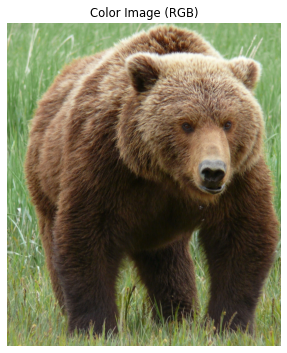

In [269]:
# =====================================================
# DISPLAY THE COLOR IMAGE
# =====================================================

# PyTorch stores images as (C, H, W) but matplotlib expects (H, W, C)
# permute(1, 2, 0) rearranges dimensions: (C, H, W) -> (H, W, C)

plt.figure(figsize=(8, 6))
plt.imshow(im.permute(1, 2, 0))
plt.title("Color Image (RGB)")
plt.axis('off')
plt.show()

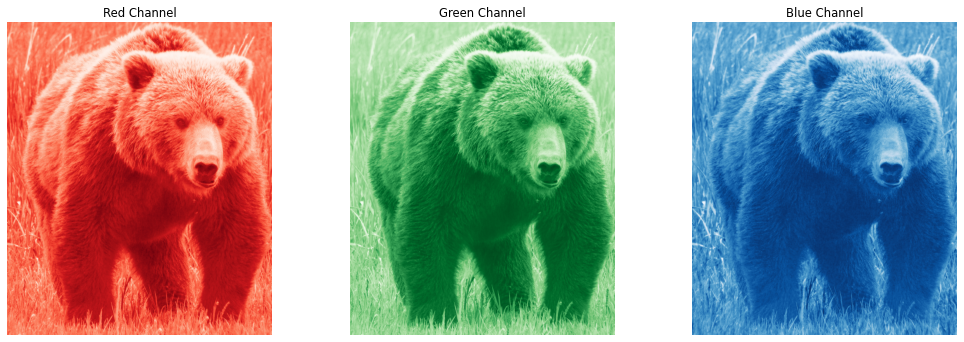

In [270]:
# =====================================================
# VISUALIZE THE INDIVIDUAL COLOR CHANNELS
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

channels = ['Red', 'Green', 'Blue']
cmaps = ['Reds', 'Greens', 'Blues']

for i, (ax, channel, cmap) in enumerate(zip(axes, channels, cmaps)):
    # im[i] gets the i-th channel; 255 - im[i] inverts so darker = more of that color
    ax.imshow(255 - im[i].numpy(), cmap=cmap)
    ax.set_title(f"{channel} Channel")
    ax.axis('off')

plt.tight_layout()
plt.show()

#### Example 2 — A synthetic image we build ourselves

No file needed — we construct every pixel directly. Because the gradients are known in advance, the three channel panels below should look exactly as designed: **Red** brightest at the bottom, **Green** brightest on the right, **Blue** a flat mid-grey everywhere. It's the same channel-visualisation code as above, just pointed at a different image.

In [271]:
# =====================================================
# EXAMPLE 2 - BUILD A SYNTHETIC RGB IMAGE BY HAND
# =====================================================

import torch

# We define every pixel ourselves so we know exactly what each channel holds:
#   Red   increases from top to bottom
#   Green increases from left to right
#   Blue  is constant everywhere
im = torch.zeros(3, 100, 100, dtype=torch.uint8)
for i in range(100):
    im[0, i, :] = int(255 * i / 100)   # Red gradient (rows)
    im[1, :, i] = int(255 * i / 100)   # Green gradient (cols)
im[2, :, :] = 128                       # Constant blue

print("Image shape:", tuple(im.shape))
print("Pixel value range:", int(im.min()), "to", int(im.max()))

Image shape: (3, 100, 100)
Pixel value range: 0 to 252


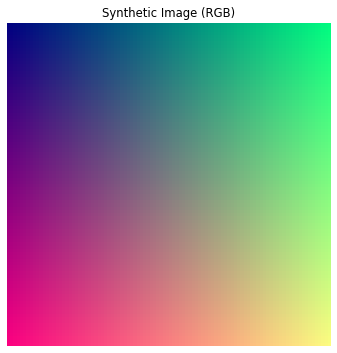

In [272]:
# =====================================================
# DISPLAY THE SYNTHETIC COLOR IMAGE
# =====================================================

plt.figure(figsize=(8, 6))
plt.imshow(im.permute(1, 2, 0))
plt.title("Synthetic Image (RGB)")
plt.axis('off')
plt.show()

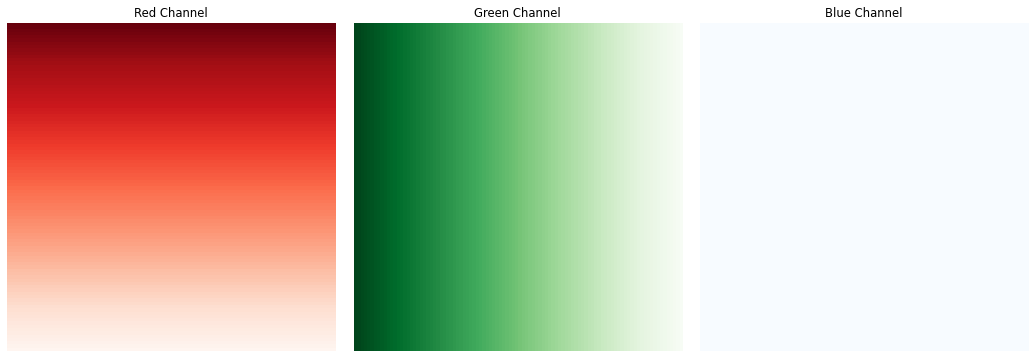

In [273]:
# =====================================================
# VISUALIZE THE SYNTHETIC IMAGE'S RGB CHANNELS
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

channels = ['Red', 'Green', 'Blue']
cmaps = ['Reds', 'Greens', 'Blues']

for i, (ax, channel, cmap) in enumerate(zip(axes, channels, cmaps)):
    ax.imshow(255 - im[i].numpy(), cmap=cmap)
    ax.set_title(f"{channel} Channel")
    ax.axis('off')

plt.tight_layout()
plt.show()

**Key insight:** Each color channel is like a separate grayscale image. A convolution on RGB:

1.  Has 3 kernels (one per channel)
2.  Applies each kernel to its channel
3.  Sums the 3 results to get one output

This means the network can learn to combine color information meaningfully (e.g., "red fur" vs "blue sky").

------------------------------------------------------------------------

### 🎮 Interactive (3D): RGB convolution — the kernel is a 3×3×**3** cube

The three numbered steps above, in 3D. One filter spans **all channels at once**: 27 input numbers → 27 weights → **one** output number.

**What to try**
- **Drag to rotate, scroll to zoom** the scene (R / G / B planes on the left, output map on the right).
- Step the stages: **① place the 3×3×3 window → ② multiply & sum each channel → ③ add the three sums → one number** — the per-channel sum strip shows the actual arithmetic.
- Switch filter-1's kernel (blur / red-pass / vertical edge) and stack **1–3 filters** to see multi-channel output.

> ⚠️ This one loads three.js from a CDN, so it needs an internet connection (the arithmetic strip works offline).

In [274]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/rgb_conv3d.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# NOTE: needs internet access (loads three.js from cdnjs).
# ============================================================================
show_viz("interactive_viz/rgb_conv3d.html", height="660px")

------------------------------------------------------------------------

# Summary

------------------------------------------------------------------------

## Key Concepts Learned

### Convolution Operation

- **What**: Sliding a kernel over an image, computing dot products
- **Formula**: Element-wise multiply, then sum
- **Purpose**: Extract local features (edges, textures, patterns)

### Kernels (Filters)

- Small matrices (typically 3×3 or 5×5)
- Different kernels detect different features
- In CNNs, kernels are **learned** from data

### Edge Detection

- Horizontal edge kernel: `[[-1,-1,-1], [0,0,0], [1,1,1]]`
- Vertical edge kernel: `[[-1,0,1], [-1,0,1], [-1,0,1]]`
- Large output = strong edge at that location

### PyTorch Convolutions

- `F.conv2d(input, weight)` - functional API
- `nn.Conv2d(in_ch, out_ch, kernel_size)` - layer API
- Input shape: `(batch, channels, height, width)`

### Stride and Padding

- **Stride**: How many pixels to move (stride=2 halves size)
- **Padding**: Zeros added around border (padding=ks//2 maintains size)
- Output size formula: `(n + 2p - k) / s + 1`

### CNN Architecture

- Stack conv layers with increasing channels
- Use stride=2 to reduce spatial dimensions
- End with Flatten to get class predictions

### Receptive Field

- The input area affecting each output pixel
- Grows with depth - deeper layers "see" more

### Color Images

- RGB = 3 channels
- Conv kernel has weights for each input channel
- Outputs are summed across channels

------------------------------------------------------------------------

## What's Next?

In future notebooks, we'll explore:

- **Batch normalization** - Stabilize training
- **ResNets** - Very deep networks with skip connections
- **Data augmentation** - Improve generalization
- **Transfer learning** - Use pre-trained models

------------------------------------------------------------------------